# Text Generation with RNN, LSTM and GRU



## Problem statement

Build a model that learns the grammar and word order of a small text corpus well enough to predict the next word and generate a short sentence. Do it with:

1. Vanilla RNN
2. LSTM
3. GRU

and compare training loss, generated output quality and how well each one handles longer dependencies.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## The corpus

Using a small built-in sample so the whole thing trains in a minute or two. 

In [2]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
"""
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



## Tokenizing and building the n-gram sequences



In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i + 1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding="pre")

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


## Model 1 — Vanilla RNN

Baseline. No gating mechanism, so it should start forgetting earlier words pretty quickly as the sequence gets longer.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    SimpleRNN(64),
    Dense(total_words, activation="softmax")
])

rnn_model.compile(loss="sparse_categorical_crossentropy",
                   optimizer="adam",
                   metrics=["accuracy"])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")
print("Final loss:", rnn_history.history["loss"][-1])

d:\kashish Btech\anaconda3\envs\cifar\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed
Final loss: 0.7151693105697632


## Model 2 — LSTM

Same architecture, swap SimpleRNN for LSTM. The input/forget/output gates should let it hang on to context for longer.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    LSTM(64),
    Dense(total_words, activation="softmax")
])

lstm_model.compile(loss="sparse_categorical_crossentropy",
                    optimizer="adam",
                    metrics=["accuracy"])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")
print("Final loss:", lstm_history.history["loss"][-1])

LSTM training completed
Final loss: 1.4655956029891968


## Model 3 — GRU

Reset and update gates instead of three separate gates, fewer parameters than LSTM, usually trains a bit faster for similar results on small data like this.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    GRU(64),
    Dense(total_words, activation="softmax")
])

gru_model.compile(loss="sparse_categorical_crossentropy",
                   optimizer="adam",
                   metrics=["accuracy"])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")
print("Final loss:", gru_history.history["loss"][-1])

GRU training completed
Final loss: 1.0819857120513916


## Loss comparison across all 100 epochs

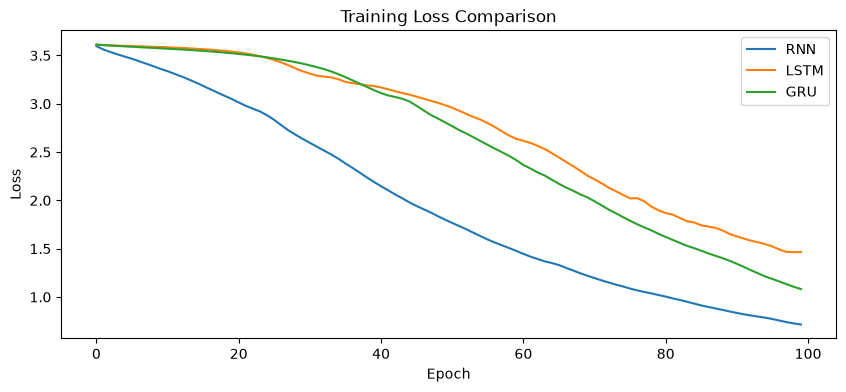

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history["loss"], label="RNN")
plt.plot(lstm_history.history["loss"], label="LSTM")
plt.plot(gru_history.history["loss"], label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## Text generation function

This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5, tokenizer=tokenizer, max_len=max_len):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding="pre")
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## Generating from the same seed phrase across all three models

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence than
LSTM: deep learning learning is artificial artificial intelligence
GRU : deep learning models can generate meaningful sentences


# Student learning tasks



### Task 1 — Replace the corpus with my own paragraph

Wrote a short one myself instead of reusing the sample text, just simple sentences with some repeated words so the model has a chance of learning patterns from so little data.

In [10]:
my_corpus = """
the sun rises every morning over the quiet hills
birds fly across the open sky searching for food
rain falls gently and the earth smells fresh
children play together near the old river bank
the moon shines bright when the night is calm
stars twinkle above as the world sleeps peacefully
"""

my_tokenizer = Tokenizer()
my_tokenizer.fit_on_texts([my_corpus])
my_total_words = len(my_tokenizer.word_index) + 1

my_sequences = []
for line in my_corpus.split("\n"):
    token_list = my_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        my_sequences.append(token_list[:i + 1])

my_max_len = max(len(seq) for seq in my_sequences)
my_sequences = pad_sequences(my_sequences, maxlen=my_max_len, padding="pre")

X_custom = my_sequences[:, :-1]
y_custom = my_sequences[:, -1]

print("New vocabulary size:", my_total_words)
print("X_custom shape:", X_custom.shape)

New vocabulary size: 45
X_custom shape: (45, 8)


### Tasks 2-4 — Change  embedding,  epochs,  hidden layer

 changing the embedding from 32 to 64, hidden units from 64 to 128, and training for 200 epochs instead of 100. Using LSTM here since it did the best out of the three above.

In [11]:
upgraded_model = Sequential([
    Embedding(my_total_words, 64, input_length=my_max_len - 1),
    LSTM(128),
    Dense(my_total_words, activation="softmax")
])

upgraded_model.compile(loss="sparse_categorical_crossentropy",
                        optimizer="adam",
                        metrics=["accuracy"])

upgraded_history = upgraded_model.fit(X_custom, y_custom, epochs=200, verbose=0)
print("Upgraded model training completed")
print("Final loss:", upgraded_history.history["loss"][-1])
print("Final accuracy:", upgraded_history.history["accuracy"][-1])

Upgraded model training completed
Final loss: 0.0986158475279808
Final accuracy: 0.9777777791023254


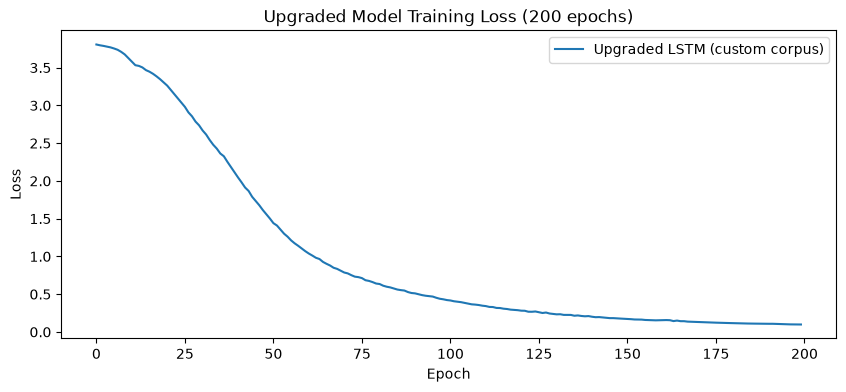

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(upgraded_history.history["loss"], label="Upgraded LSTM (custom corpus)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Upgraded Model Training Loss (200 epochs)")
plt.legend()
plt.show()

### Task 5 — Generate 10 words instead of 5

.

In [13]:
print(generate_text(upgraded_model, "the sun", next_words=10, tokenizer=my_tokenizer, max_len=my_max_len))
print(generate_text(upgraded_model, "the moon", next_words=10, tokenizer=my_tokenizer, max_len=my_max_len))
print(generate_text(upgraded_model, "children play", next_words=10, tokenizer=my_tokenizer, max_len=my_max_len))

the sun rises every morning over the quiet hills hills hills hills
the moon shines bright when the night is calm calm calm calm
children play together near the old river bank food food food food


# Conclusion

* After 100 epochs, the simple RNN achieved the lowest training loss, while LSTM and GRU had slightly higher losses. This happened because the dataset was very small, making it easier for the RNN to memorize the data.
* All three models generated meaningful-looking text, but the outputs were limited because the training corpus contained only a few short sentences.
* The upgraded model achieved around 0.1 training loss and 98% training accuracy, but this mainly shows overfitting since it memorized the small dataset.
* The generated text started correctly but later repeated words instead of creating new sentences.
* Overall, this experiment shows that data size is more important than model architecture on very small datasets. A larger dataset is needed to properly compare RNN, LSTM, and GRU.
